In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
#load merchent engagement dataset
df = pd.read_csv(
    "../data/samples/yelp_merchant_engagement.csv"
)

print("Dataset shape:", df.shape)
print("Number of unique businesses:", df["business_id"].nunique())

Dataset shape: (8812, 28)
Number of unique businesses: 8812


In [3]:
#validate business uniqueness
duplicate_business_ids = df["business_id"].duplicated().sum()

print("Duplicate business IDs:", duplicate_business_ids)

assert duplicate_business_ids == 0

Duplicate business IDs: 0


In [4]:
#Check that the required trend columns exist
trend_columns = [
    "review_change",
    "checkin_change",
    "rating_change"
]

print("Trend columns:")
print(df[trend_columns].columns.tolist())

Trend columns:
['review_change', 'checkin_change', 'rating_change']


In [5]:
#Descriptive statistics
df[trend_columns].describe()

,review_change,checkin_change,rating_change
count,8812.000000,8812.000000,3602.000000
mean,-0.059010,0.201657,-0.094015
std,4.346674,4.539598,1.175381
min,-52.000000,-93.000000,-4.000000
25%,-1.000000,0.000000,-0.599038
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.428571
max,52.000000,75.000000,4.000000


In [6]:
# Investigate businesses with missing rating change

rating_missing = df["rating_change"].isna()

print("Businesses with missing rating change:", rating_missing.sum())
print("Businesses with valid rating change:", (~rating_missing).sum())

print("\nReview counts for businesses with missing rating change:")
print(
    df.loc[
        rating_missing,
        [
            "total_reviews",
            "recent_reviews",
            "earlier_reviews"
        ]
    ].describe()
)

Businesses with missing rating change: 5210
Businesses with valid rating change: 3602

Review counts for businesses with missing rating change:
       total_reviews  recent_reviews  earlier_reviews
count    5210.000000     5210.000000      5210.000000
mean       54.590595        0.404607         0.243762
std        95.285071        2.295467         0.969532
min         5.000000        0.000000         0.000000
25%        10.000000        0.000000         0.000000
50%        23.000000        0.000000         0.000000
75%        57.000000        0.000000         0.000000
max      1203.000000       52.000000        35.000000


In [7]:
# Check how many businesses have reviews in each period

print("Recent reviews > 0:",
      (df["recent_reviews"] > 0).sum())

print("Earlier reviews > 0:",
      (df["earlier_reviews"] > 0).sum())

print("Both periods > 0:",
      (
          (df["recent_reviews"] > 0) &
          (df["earlier_reviews"] > 0)
      ).sum())

Recent reviews > 0: 4250
Earlier reviews > 0: 4232
Both periods > 0: 3602


### Handling Missing Rating Trends

`rating_change` is only available for businesses with reviews in both the recent and earlier periods. Businesses without reviews in one or both periods have a missing (`NaN`) rating trend because a change in average rating cannot be calculated reliably.

For the engagement scoring stage, missing `rating_change` values are treated as **0 (neutral change)**. This does not mean that the business's rating actually remained unchanged; rather, it provides a neutral contribution to the scoring model when there is insufficient data to measure a rating trend.

The original `rating_change` column is retained unchanged, while a separate `rating_change_for_score` column is created with missing values replaced by 0.

Because Min-Max normalization is applied after this treatment, a neutral rating change of 0 maps to the midpoint of the observed rating-change range (0.5 when the range is -4 to +4).

In [8]:
# Create a scoring version of rating change
# Missing rating trends are treated as neutral (0)

df["rating_change_for_score"] = (
    df["rating_change"].fillna(0)
)

print("Original rating_change NaNs:",
      df["rating_change"].isna().sum())

print("rating_change_for_score NaNs:",
      df["rating_change_for_score"].isna().sum())

Original rating_change NaNs: 5210
rating_change_for_score NaNs: 0


In [9]:
#check for missing values
print("Missing values in trend columns:")

print(
    df[trend_columns]
    .isna()
    .sum()
)

Missing values in trend columns:
review_change        0
checkin_change       0
rating_change     5210
dtype: int64


In [10]:
#check zero chekin business
zero_checkin_businesses = (
    df["total_checkins"] == 0
).sum()

print(
    "Businesses with zero total check-ins:",
    zero_checkin_businesses
)

Businesses with zero total check-ins: 229


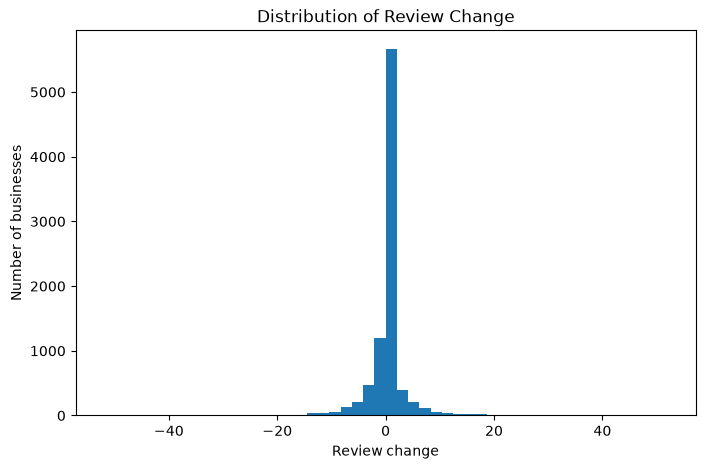

In [11]:
#Histogram for review change
plt.figure(figsize=(8, 5))

plt.hist(
    df["review_change"].dropna(),
    bins=50
)

plt.xlabel("Review change")
plt.ylabel("Number of businesses")
plt.title("Distribution of Review Change")

plt.show()

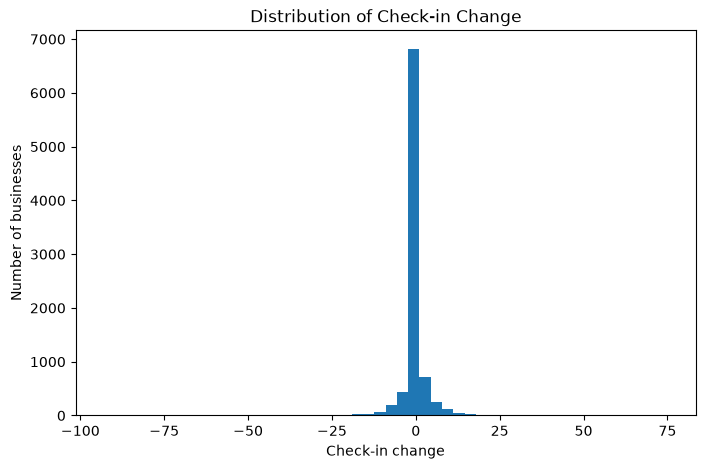

In [12]:
#histogram checkin change
plt.figure(figsize=(8, 5))

plt.hist(
    df["checkin_change"].dropna(),
    bins=50
)

plt.xlabel("Check-in change")
plt.ylabel("Number of businesses")
plt.title("Distribution of Check-in Change")

plt.show()

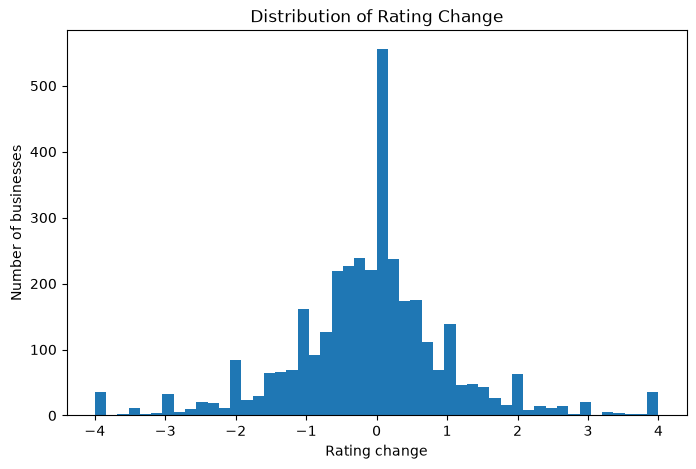

In [13]:
#histogram rating change
plt.figure(figsize=(8, 5))

plt.hist(
    df["rating_change"].dropna(),
    bins=50
)

plt.xlabel("Rating change")
plt.ylabel("Number of businesses")
plt.title("Distribution of Rating Change")

plt.show()

### Normalization Method

The three merchant engagement trend metrics — `review_change`, `checkin_change`, and `rating_change` — have different scales and distributions. Min-Max normalization is used to transform the trend metrics to a common 0–1 scale before combining them into the engagement score.

Distribution histograms were reviewed before normalization. Although `review_change` and `checkin_change` are concentrated around zero with relatively long tails, the observed ranges are not considered evidence of erroneous or extreme outliers. The rating-change metric is naturally bounded.

Therefore, no winsorization or outlier capping is applied. The observed values are retained because they represent genuine differences in merchant activity.

For `rating_change`, businesses without sufficient review history have missing values. These missing values are treated as `0` (neutral change) **only for scoring**, using the separate `rating_change_for_score` column. The original `rating_change` values remain unchanged.

### Min-Max Normalization

To make the three merchant engagement trend metrics comparable before combining them into a single score, Min-Max normalization is applied.

For each metric, the normalized value is calculated as:

$$x_{\text{norm}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$

where:

- $x$ = the observed value for a business
- $x_{\text{min}}$ = the minimum observed value of that metric
- $x_{\text{max}}$ = the maximum observed value of that metric

This transforms each trend metric to a common scale from **0 to 1**:

- **0** = the lowest observed value
- **1** = the highest observed value
- Values between 0 and 1 represent the relative position of a business within the observed range.

Min-Max normalization is used because `review_change`, `checkin_change`, and `rating_change_for_score` have different numerical scales and need to be placed on a common scale before weighted scoring.

The original raw trend columns are retained and are not overwritten.

In [14]:
scaler = MinMaxScaler()

In [15]:
#define the metrics to normalize
scoring_trend_columns = [
    "review_change",
    "checkin_change",
    "rating_change_for_score"
]

normalized_columns = [
    "review_trend_norm",
    "checkin_trend_norm",
    "rating_trend_norm"
]

print("Metrics to normalize:")
print(scoring_trend_columns)

Metrics to normalize:
['review_change', 'checkin_change', 'rating_change_for_score']


In [16]:
#apply min-max normalization
df[normalized_columns] = scaler.fit_transform(
    df[scoring_trend_columns]
)

print("Min-Max normalization completed.")

Min-Max normalization completed.


In [17]:
#verify normalized ranges
for column in normalized_columns:
    print(
        column,
        "| min:", df[column].min(),
        "| max:", df[column].max()
    )

review_trend_norm | min: 0.0 | max: 1.0
checkin_trend_norm | min: 0.0 | max: 0.9999999999999999
rating_trend_norm | min: 0.0 | max: 1.0


In [18]:
#formal normalization validation
for column in normalized_columns:
    valid_values = df[column].dropna()

    assert valid_values.between(0, 1).all()

print("All normalized trend values are within [0, 1].")

All normalized trend values are within [0, 1].


In [19]:
#verify the neutral rating treatment
missing_rating_mask = df["rating_change"].isna()

print(
    "Businesses with missing rating_change:",
    missing_rating_mask.sum()
)

print(
    "Normalized rating values for businesses with missing rating_change:"
)

print(
    df.loc[
        missing_rating_mask,
        "rating_trend_norm"
    ].value_counts()
)

Businesses with missing rating_change: 5210
Normalized rating values for businesses with missing rating_change:
rating_trend_norm
0.5    5210
Name: count, dtype: int64


In [20]:
#compare raw and normalized values
df[
    [
        "business_id",
        "name",
        "review_change",
        "review_trend_norm",
        "checkin_change",
        "checkin_trend_norm",
        "rating_change",
        "rating_change_for_score",
        "rating_trend_norm"
    ]
].head(10)

,business_id,name,review_change,review_trend_norm,checkin_change,checkin_trend_norm,rating_change,rating_change_for_score,rating_trend_norm
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,4,0.538462,4,0.577381,3.800000,3.800000,0.975000
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,16,0.653846,-8,0.505952,0.081699,0.081699,0.510212
2,ROeacJQwBeh05Rqg7F6TCg,BAP,5,0.548077,1,0.559524,-0.500000,-0.500000,0.437500
3,QdN72BWoyFypdGJhhI5r7g,Bar One,0,0.500000,0,0.553571,NaN,0.000000,0.500000
4,Mjboz24M9NlBeiOJKLEd_Q,DeSandro on Main,0,0.500000,0,0.553571,NaN,0.000000,0.500000
5,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,1,0.509615,6,0.589286,0.300000,0.300000,0.537500
6,uI9XODGY_2_ieTE6xJ0myw,Roman Forum,0,0.500000,0,0.553571,NaN,0.000000,0.500000
7,JgpnXv_0XhV3SfbfB50nxw,Joe's Pizza,0,0.500000,0,0.553571,NaN,0.000000,0.500000
8,ppFCk9aQkM338Rgwpl2F5A,Wawa,0,0.500000,0,0.553571,-3.000000,-3.000000,0.125000
9,RK6-cJ9hj53RzOlCBmpT-g,Impasto,0,0.500000,0,0.553571,NaN,0.000000,0.500000


In [21]:
#check the shape and uniqueness
print("Dataset shape:", df.shape)
print("Unique businesses:", df["business_id"].nunique())
print("Duplicate business IDs:", df["business_id"].duplicated().sum())

Dataset shape: (8812, 32)
Unique businesses: 8812
Duplicate business IDs: 0


In [22]:
assert len(df) == 8812
assert df["business_id"].nunique() == 8812
assert df["business_id"].duplicated().sum() == 0

print("Dataset validation passed.")

Dataset validation passed.


In [23]:
#check the new normalized columns
print("Normalized columns:")
print(normalized_columns)

print("\nMissing values:")
print(df[normalized_columns].isna().sum())

Normalized columns:
['review_trend_norm', 'checkin_trend_norm', 'rating_trend_norm']

Missing values:
review_trend_norm     0
checkin_trend_norm    0
rating_trend_norm     0
dtype: int64


In [24]:
#save the file
output_path = "../data/samples/yelp_merchant_engagement.csv"

df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ../data/samples/yelp_merchant_engagement.csv


In [25]:
#verify the saved file
df_check = pd.read_csv(output_path)

print("Saved dataset shape:", df_check.shape)
print("Unique businesses:", df_check["business_id"].nunique())
print("Duplicate business IDs:", df_check["business_id"].duplicated().sum())

Saved dataset shape: (8812, 32)
Unique businesses: 8812
Duplicate business IDs: 0


In [26]:
assert df_check.shape == df.shape
assert df_check["business_id"].nunique() == 8812
assert df_check["business_id"].duplicated().sum() == 0

print("Final saved-file validation passed.")

Final saved-file validation passed.


In [27]:
for column in normalized_columns:
    print(
        column,
        "| min:", df_check[column].min(),
        "| max:", df_check[column].max()
    )

    assert df_check[column].between(0, 1).all()

print("\nFinal normalization validation passed.")

review_trend_norm | min: 0.0 | max: 1.0
checkin_trend_norm | min: 0.0 | max: 1.0
rating_trend_norm | min: 0.0 | max: 1.0

Final normalization validation passed.


In [ ]:
#load data
import pandas as pd

df = pd.read_csv("../data/samples/yelp_merchant_engagement.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (8812, 32)

Columns:
['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours', 'total_reviews', 'earlier_reviews', 'recent_reviews', 'review_growth', 'average_rating', 'earlier_average_rating', 'recent_average_rating', 'rating_change', 'total_checkins', 'earlier_checkins', 'recent_checkins', 'checkin_growth', 'review_change', 'checkin_change', 'rating_change_for_score', 'review_trend_norm', 'checkin_trend_norm', 'rating_trend_norm']


In [29]:
#verify the normalized columns
norm_cols = [
    "review_trend_norm",
    "checkin_trend_norm",
    "rating_trend_norm"
]

print(df[norm_cols].describe())

       review_trend_norm  checkin_trend_norm  rating_trend_norm
count        8812.000000         8812.000000        8812.000000
mean            0.499433            0.554772           0.495196
std             0.041795            0.027021           0.094104
min             0.000000            0.000000           0.000000
25%             0.490385            0.553571           0.500000
50%             0.500000            0.553571           0.500000
75%             0.500000            0.553571           0.500000
max             1.000000            1.000000           1.000000


In [30]:
#check correlations
correlation_matrix = df[norm_cols].corr()

correlation_matrix

,review_trend_norm,checkin_trend_norm,rating_trend_norm
review_trend_norm,1.000000,0.477665,0.012398
checkin_trend_norm,0.477665,1.000000,0.017335
rating_trend_norm,0.012398,0.017335,1.000000


In [31]:
#look at distribution statistic
distribution_summary = df[norm_cols].agg(
    ["min", "mean", "median", "std", "max"]
).T

distribution_summary

,min,mean,median,std,max
review_trend_norm,0.0,0.499433,0.500000,0.041795,1.0
checkin_trend_norm,0.0,0.554772,0.553571,0.027021,1.0
rating_trend_norm,0.0,0.495196,0.500000,0.094104,1.0


Review and check-in trends show moderate correlation `(0.478)`, while rating trend is largely independent of both. All three components are retained because they represent distinct dimensions of merchant engagement. The original `40:30:20` weighting is preserved and re-scaled to `44:33:22` because sentiment is not yet available.

In [32]:
#create the provisional score
df["engagement_score"] = (
    (40 / 90) * df["review_trend_norm"]
    + (30 / 90) * df["checkin_trend_norm"]
    + (20 / 90) * df["rating_trend_norm"]
)

In [33]:
#validate the score
print("Engagement score range:")
print("Min:", df["engagement_score"].min())
print("Max:", df["engagement_score"].max())

print("\nMissing values:")
print(df["engagement_score"].isna().sum())

print("\nSummary:")
print(df["engagement_score"].describe())

Engagement score range:
Min: 0.2624236874236874
Max: 0.8748181687996502

Missing values:
0

Summary:
count    8812.000000
mean        0.516938
std         0.032241
min         0.262424
25%         0.513584
50%         0.517857
75%         0.519841
max         0.874818
Name: engagement_score, dtype: float64


In [34]:
#add explicit assertions
assert df["engagement_score"].notna().all()
assert df["engagement_score"].between(0, 1).all()

print("All engagement score validations passed.")

All engagement score validations passed.


In [35]:
#calculate alternative score
df["engagement_score_equal"] = (
    (1 / 3) * df["review_trend_norm"]
    + (1 / 3) * df["checkin_trend_norm"]
    + (1 / 3) * df["rating_trend_norm"]
)

print(df[["engagement_score", "engagement_score_equal"]].describe())

       engagement_score  engagement_score_equal
count       8812.000000             8812.000000
mean           0.516938                0.516467
std            0.032241                0.037412
min            0.262424                0.313278
25%            0.513584                0.514652
50%            0.517857                0.517857
75%            0.519841                0.519841
max            0.874818                0.820622


In [37]:
#create the two rankings
df["rank_current"] = df["engagement_score"].rank(
    ascending=False,
    method="min"
)

df["rank_equal"] = df["engagement_score_equal"].rank(
    ascending=False,
    method="min"
)

df["rank_change"] = df["rank_current"] - df["rank_equal"]

print("Average absolute rank change:",
      df["rank_change"].abs().mean())

print("Median absolute rank change:",
      df["rank_change"].abs().median())

print("Maximum absolute rank change:",
      df["rank_change"].abs().max())

Average absolute rank change: 233.6729459827508
Median absolute rank change: 31.0
Maximum absolute rank change: 6257.0


**Weight sensitivity:** An equal-weight alternative (33.33% review,
33.33% check-in, 33.33% rating) was compared with the primary
44.44% / 33.33% / 22.22% weighting. The median absolute ranking change
was 31 positions across 8,812 merchants, while the mean absolute
ranking change was approximately 234 positions. Some merchants showed
much larger changes, with a maximum rank change of 6,257 positions.

This indicates that the weighting scheme has a meaningful effect on
individual merchant rankings, particularly for merchants with
imbalanced trend profiles. The original 40:30:20 business weighting,
re-scaled to 44.44% / 33.33% / 22.22% in the absence of sentiment,
was retained because it reflects the intended relative importance of
review, check-in, and rating trends. The score will be revisited when
the sentiment component is introduced in Step 15.

In [38]:
#top 10 merchants
top_10 = (
    df.sort_values("engagement_score", ascending=False)
      [
          [
              "business_id",
              "name",
              "city",
              "stars",
              "review_change",
              "checkin_change",
              "rating_change",
              "review_trend_norm",
              "checkin_trend_norm",
              "rating_trend_norm",
              "engagement_score"
          ]
      ]
      .head(10)
)

top_10

,business_id,name,city,stars,review_change,checkin_change,rating_change,review_trend_norm,checkin_trend_norm,rating_trend_norm,engagement_score
8361,ytynqOUb3hjKeJfRj5Tshw,Reading Terminal Market,Philadelphia,4.5,50,73,-0.055996,0.980769,0.988095,0.493000,0.874818
4764,K1h1Cwy1VSGdjKuw-GM9Iw,Matcha Cafe Maiko,Philadelphia,4.0,46,70,NaN,0.942308,0.970238,0.500000,0.853327
2207,6IwF2rpoaiR_W6DzOvuceA,Victory Brewing Company Philadelphia,Philadelphia,4.5,52,36,NaN,1.000000,0.767857,0.500000,0.811508
3307,FkXzqvQiagj9eCgLVd1T7g,Sushi Yama,Tampa,4.5,46,44,NaN,0.942308,0.815476,0.500000,0.801740
1262,Sv1MEZP-mMfp8SmE0hwYEA,Terakawa Ramen,Philadelphia,4.5,27,75,-0.191667,0.759615,1.000000,0.476042,0.776727
8619,kD03gNnQrHarCz97s1BNDQ,Mandola's Italian Kitchen,Tampa,3.5,49,24,NaN,0.971154,0.696429,0.500000,0.774878
4591,U2bIdbGjmmpw3BQj20dn5g,Zimo Bakery & Cafe,Tampa,4.5,39,45,NaN,0.875000,0.821429,0.500000,0.773810
1746,41dW3laDEV0boHre1utRgw,Bubba’s 33,Tampa,4.0,41,39,NaN,0.894231,0.785714,0.500000,0.770452
3141,gpRaW4K8eYjbGHzcglwF_A,BellaBrava,Tampa,4.0,31,34,NaN,0.798077,0.755952,0.500000,0.717796
6410,ntiIq1FNqduOyyowMFGh5A,Nan Zhou Hand Drawn Noodle House,Philadelphia,4.0,30,34,0.041796,0.788462,0.755952,0.505224,0.714684


In [40]:
#bottom 10 merchants
bottom_10 = (
    df.sort_values("engagement_score", ascending=True)
      [
          [
              "business_id",
              "name",
              "city",
              "stars",
              "review_change",
              "checkin_change",
              "rating_change",
              "review_trend_norm",
              "checkin_trend_norm",
              "rating_trend_norm",
              "engagement_score"
          ]
      ]
      .head(10)
)

bottom_10

,business_id,name,city,stars,review_change,checkin_change,rating_change,review_trend_norm,checkin_trend_norm,rating_trend_norm,engagement_score
1864,V5joRorS5dBNDXD669n6jg,Germantown Garden,Philadelphia,3.0,-52,-12,-0.338462,0.000000,0.482143,0.457692,0.262424
3337,hE6YsHHV0fCz_UrGS4o6VA,Salt Shack on the Bay,Tampa,3.5,-39,-35,-0.038041,0.125000,0.345238,0.495245,0.280689
1153,C_csOMzSkq3Ufau_rKmTmg,Luv Child,Tampa,4.5,-40,-32,-0.000795,0.115385,0.363095,0.499901,0.283403
6842,R_5X96OM-b0fF9pZbzzy0g,Santoro's Pizzeria,Tampa,4.5,-42,-17,-0.492424,0.096154,0.452381,0.438447,0.290961
8043,QHWYlmVbLC3K6eglWoHVvA,Datz,Tampa,4.0,-9,-93,0.465554,0.413462,0.000000,0.558194,0.307804
4509,ZNWox30LIv7hV5k5YP8tCQ,Bar-Ly Chinatown,Philadelphia,4.0,-35,-7,-1.330808,0.163462,0.511905,0.333649,0.317429
3319,2jRrqwGjgHgJ9rn0Ptaxuw,Fuzion Spice,Tampa,5.0,-24,-49,0.285714,0.269231,0.261905,0.535714,0.326007
151,UGebrYgNZrMzbGbcI01JWA,Hiccups & Churroholic,Tampa,4.5,-33,-27,0.161836,0.182692,0.392857,0.520229,0.327756
8450,XTjRoZEPq5X5UDKUBR7s-A,Awful Waffle,Tampa,4.5,-28,-22,-0.911765,0.230769,0.422619,0.386029,0.329221
6037,1Vo4BLw75ntATAJHYsxO3g,Whiskey Joe's Bar & Grill - Tampa,Tampa,3.0,-38,-4,-0.491597,0.134615,0.529762,0.438550,0.333872


In [41]:
rating_check = df[
    df["rating_change"].isna()
][
    [
        "business_id",
        "name",
        "rating_change",
        "rating_trend_norm",
        "engagement_score"
    ]
]

print("Rows with missing rating_change:", len(rating_check))
print("\nNormalized values for those rows:")
print(rating_check["rating_trend_norm"].value_counts(dropna=False))

Rows with missing rating_change: 5210

Normalized values for those rows:
rating_trend_norm
0.5    5210
Name: count, dtype: int64


In [42]:
print(
    "Missing rating_change:",
    df["rating_change"].isna().sum()
)

print(
    "Missing rating_trend_norm:",
    df["rating_trend_norm"].isna().sum()
)

Missing rating_change: 5210
Missing rating_trend_norm: 0


Missing rating trend values were intentionally treated as neutral
during Step 12. Where `rating_change` was unavailable, the resulting
`rating_trend_norm` was assigned a neutral value of 0.5 rather than
penalizing or rewarding the merchant. This treatment was retained when
calculating the engagement score.

In [43]:
# Remove sensitivity-analysis columns
diagnostic_cols = [
    "engagement_score_equal",
    "rank_current",
    "rank_equal",
    "rank_change"
]

df = df.drop(columns=diagnostic_cols)

print("Final shape:", df.shape)
print("Engagement score column present:", "engagement_score" in df.columns)

Final shape: (8812, 33)
Engagement score column present: True


In [44]:
#save the finalized work
output_path = "../data/samples/yelp_merchant_engagement.csv"

df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print("Saved dataset shape:", df.shape)

Saved: ../data/samples/yelp_merchant_engagement.csv
Saved dataset shape: (8812, 33)


In [45]:
#final validation
# Reload the saved file
df_check = pd.read_csv(output_path)

assert df_check.shape == df.shape
assert df_check["business_id"].is_unique
assert not df_check.duplicated().any()
assert df_check["engagement_score"].notna().all()
assert df_check["engagement_score"].between(0, 1).all()

print("Final validation passed.")
print("Shape:", df_check.shape)
print("Unique businesses:", df_check["business_id"].nunique())
print("Duplicate rows:", df_check.duplicated().sum())
print("Missing engagement scores:", df_check["engagement_score"].isna().sum())
print(
    "Engagement score range:",
    df_check["engagement_score"].min(),
    "to",
    df_check["engagement_score"].max()
)

Final validation passed.
Shape: (8812, 33)
Unique businesses: 8812
Duplicate rows: 0
Missing engagement scores: 0
Engagement score range: 0.2624236874236874 to 0.8748181687996502


## Step 13 — Merchant Engagement Score: Final Summary

A provisional merchant engagement score was created by combining the three
available normalized trend metrics:

- `review_trend_norm` — 44.44%
- `checkin_trend_norm` — 33.33%
- `rating_trend_norm` — 22.22%

The original build-plan weighting of 40% review, 30% check-in, 20% rating,
and 10% sentiment was re-scaled to the available three components because
sentiment analysis has not yet been completed. The sentiment component will
be incorporated and the final weighting revisited in Step 15.

### Weighting rationale

Correlation analysis showed a moderate relationship between review and
check-in trends (`r = 0.478`), while rating trend was largely independent
of both review (`r = 0.012`) and check-in (`r = 0.017`) trends. All three
components were retained because they represent distinct dimensions of
merchant engagement.

The normalized distributions were also examined. Review and check-in trends
were relatively concentrated, while rating trend showed greater variation.
No additional variance-based reweighting was applied because all components
were already Min-Max normalized to a common [0, 1] scale.

### Score formula

The provisional engagement score is:

`engagement_score = (40/90 × review_trend_norm)
                  + (30/90 × checkin_trend_norm)
                  + (20/90 × rating_trend_norm)`

A higher score indicates stronger recent merchant engagement trends.

### Missing-value treatment

There are no missing values in the resulting `engagement_score`. Missing
`rating_change` values were intentionally treated as neutral during Step 12,
with the corresponding `rating_trend_norm` assigned a value of 0.5. This
treatment was retained in the engagement score calculation.

### Sensitivity analysis

An alternative equal-weight score (33.33% review, 33.33% check-in, and
33.33% rating) was evaluated to assess ranking sensitivity.

The comparison produced:

- Mean absolute rank change: approximately 234 positions
- Median absolute rank change: 31 positions
- Maximum absolute rank change: 6,257 positions

This indicates that the weighting scheme has a meaningful effect on some
individual merchant rankings, particularly merchants with substantially
different review, check-in, and rating trends. The original 40:30:20
business weighting, re-scaled to 44.44%:33.33%:22.22%, was retained because
it reflects the intended relative importance of the three engagement
dimensions.

### Ranking sanity check

The highest-ranked merchants generally showed strong positive recent review
and check-in activity, while the lowest-ranked merchants generally showed
declining recent activity. The resulting ranking was therefore considered
intuitively consistent with the intended definition of merchant engagement.

### Final validation

The saved dataset was reloaded and validated after scoring:

- Shape: **8,812 rows × 33 columns**
- Unique businesses: **8,812**
- Duplicate rows: **0**
- Missing engagement scores: **0**
- Engagement score range: **0.2624–0.8748**
- All engagement scores confirmed within the theoretical [0, 1] range

**Output:** `data/samples/yelp_merchant_engagement.csv`

**Note:** This is a provisional three-component engagement score.
The scoring framework will be revisited when the sentiment component is
introduced in Step 15.